# Crafting a time series forecasting model

This model will be trained on the stock price data of Gold. The data will be picked from yfinance(a python library used by quant devs for such purposes), the data will be picked from jan 2010 to today's date and to keep model fresh to the seasonality, I'll be crafting a separate script where the same model will be trained on the monthly seasonality basis of the data. The model will be trained on the daily data and then the same model will be trained on the monthly data, this way we can capture both the short term and long term patterns in the data.

In order to find out the best sequence to sequence predictionary model, I'll do experiment on LSTM, GRU and Conv1D and the winner model among these 3 will be pushed into the cloud for making the prediction, and this cloud fetched model will be further trained based on the above mentioned strategy of training.

## Setting pre-requisites

### Importing libraries

In [37]:
import torch 
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import MinMaxScaler
from yfinance import download
from pandas import read_csv, to_datetime
import numpy as np
from datetime import datetime

from typing import Any

### Checking for GPU availability

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### Acquiring the gold price data via yfinance

In [ ]:
# use the yfinance library to download the gold price data from jan 2010 to today's date
# only the 'Close' price will be used for modeling
data = download("GC=F", start="2010-01-01", end=datetime.today().strftime("%Y-%m-%d"))
data = data[["Close"]]
data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close
Ticker,GC=F
Date,
2010-01-04,1117.699951
2010-01-05,1118.099976
2010-01-06,1135.900024
2010-01-07,1133.099976
2010-01-08,1138.199951


### Saving the acquired 'Close' with current datetime

In [ ]:
data.to_csv(f"../data/raw/gold_price_data_{datetime.today().strftime('%Y-%m-%d')}.csv", index=True)

# verifying the saved data
saved_data = read_csv(f"../data/raw/gold_price_data_{datetime.today().strftime('%Y-%m-%d')}.csv")
saved_data.head()

,Price,Close
0,Ticker,GC=F
1,Date,NaN
2,2010-01-04,1117.699951171875
3,2010-01-05,1118.0999755859375
4,2010-01-06,1135.9000244140625


In [ ]:
saved_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4100 entries, 0 to 4099
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Price   4100 non-null   object
 1   Close   4099 non-null   object
dtypes: object(2)
memory usage: 64.2+ KB


In [ ]:
saved_data.describe()

,Price,Close
count,4100,4099
unique,4100,3343
top,2026-04-21,1273.699951171875
freq,1,6


### Preprocessing the data

In [ ]:
saved_data

,Price,Close
0,Ticker,GC=F
1,Date,NaN
2,2010-01-04,1117.699951171875
3,2010-01-05,1118.0999755859375
4,2010-01-06,1135.9000244140625
...,...,...
4095,2026-04-15,4800.0
4096,2026-04-16,4785.39990234375
4097,2026-04-17,4857.60009765625
4098,2026-04-20,4806.60009765625


In [3]:
saved_data = read_csv(f"../data/raw/gold_price_data_{datetime.today().strftime('%Y-%m-%d')}.csv")
saved_data.columns

Index(['Price', 'Close'], dtype='object')

In [4]:
saved_data.index

RangeIndex(start=0, stop=4100, step=1)

In [6]:
saved_data['Price']

0           Ticker
1             Date
2       2010-01-04
3       2010-01-05
4       2010-01-06
           ...    
4095    2026-04-15
4096    2026-04-16
4097    2026-04-17
4098    2026-04-20
4099    2026-04-21
Name: Price, Length: 4100, dtype: object

In [11]:
saved_data.select_dtypes(include=['object']).columns

Index(['Price', 'Close'], dtype='object')

In [12]:
saved_data.drop([0,1], inplace=True)

saved_data

,Price,Close
2,2010-01-04,1117.699951171875
3,2010-01-05,1118.0999755859375
4,2010-01-06,1135.9000244140625
5,2010-01-07,1133.0999755859375
6,2010-01-08,1138.199951171875
...,...,...
4095,2026-04-15,4800.0
4096,2026-04-16,4785.39990234375
4097,2026-04-17,4857.60009765625
4098,2026-04-20,4806.60009765625


In [13]:
saved_data.rename(columns={'Price': 'Date', 'Close': 'closing_price'}, inplace=True)

saved_data

,Date,closing_price
2,2010-01-04,1117.699951171875
3,2010-01-05,1118.0999755859375
4,2010-01-06,1135.9000244140625
5,2010-01-07,1133.0999755859375
6,2010-01-08,1138.199951171875
...,...,...
4095,2026-04-15,4800.0
4096,2026-04-16,4785.39990234375
4097,2026-04-17,4857.60009765625
4098,2026-04-20,4806.60009765625


In [15]:
saved_data.set_index('Date', inplace=True)
saved_data.index = to_datetime(saved_data.index)

saved_data

,closing_price
Date,
2010-01-04,1117.699951171875
2010-01-05,1118.0999755859375
2010-01-06,1135.9000244140625
2010-01-07,1133.0999755859375
2010-01-08,1138.199951171875
...,...
2026-04-15,4800.0
2026-04-16,4785.39990234375
2026-04-17,4857.60009765625


In [18]:
saved_data.index, saved_data.columns, saved_data.dtypes

print("saved_data.index:", saved_data.index)
print("saved_data.columns:", saved_data.columns)
print("saved_data.dtypes:", saved_data.dtypes)

saved_data.index: DatetimeIndex(['2010-01-04', '2010-01-05', '2010-01-06', '2010-01-07',
               '2010-01-08', '2010-01-11', '2010-01-12', '2010-01-13',
               '2010-01-14', '2010-01-15',
               ...
               '2026-04-08', '2026-04-09', '2026-04-10', '2026-04-13',
               '2026-04-14', '2026-04-15', '2026-04-16', '2026-04-17',
               '2026-04-20', '2026-04-21'],
              dtype='datetime64[ns]', name='Date', length=4098, freq=None)
saved_data.columns: Index(['closing_price'], dtype='object')
saved_data.dtypes: closing_price    object
dtype: object


In [21]:
type_mapping = {
    'closing_price': 'float64'
}

saved_data = saved_data.astype(type_mapping)

saved_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4098 entries, 2010-01-04 to 2026-04-21
Data columns (total 1 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   closing_price  4098 non-null   float64
dtypes: float64(1)
memory usage: 64.0 KB


<Axes: xlabel='Date'>

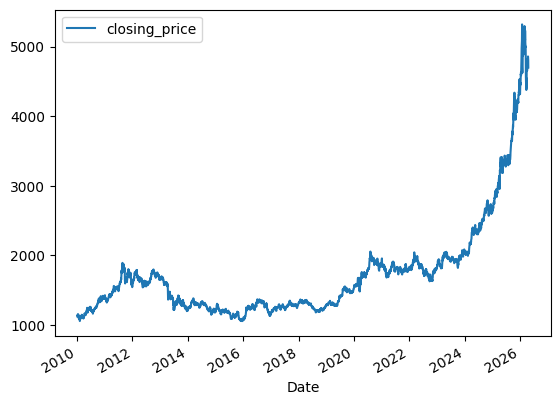

In [22]:
saved_data.plot()

### Saving the preprocessed data for future use

In [ ]:
saved_data.to_csv(f"../data/processed/gold_data_preprocessed_{datetime.now().strftime('%Y-%m-%d')}.csv", index_label='Date')

preprcossed_data = read_csv(
    f"../data/processed/gold_data_preprocessed_{datetime.now().strftime('%Y-%m-%d')}.csv",
    index_col='Date',
    parse_dates=True
)

preprcossed_data

,closing_price
Date,
2010-01-04,1117.699951
2010-01-05,1118.099976
2010-01-06,1135.900024
2010-01-07,1133.099976
2010-01-08,1138.199951
...,...
2026-04-15,4800.000000
2026-04-16,4785.399902
2026-04-17,4857.600098


<Axes: xlabel='Date'>

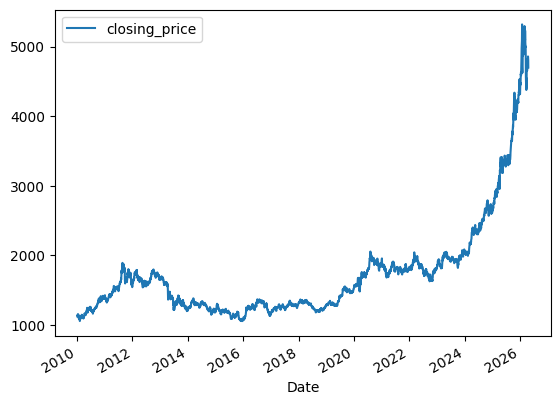

In [37]:
preprcossed_data.plot()

In [38]:
preprcossed_data.index

DatetimeIndex(['2010-01-04', '2010-01-05', '2010-01-06', '2010-01-07',
               '2010-01-08', '2010-01-11', '2010-01-12', '2010-01-13',
               '2010-01-14', '2010-01-15',
               ...
               '2026-04-08', '2026-04-09', '2026-04-10', '2026-04-13',
               '2026-04-14', '2026-04-15', '2026-04-16', '2026-04-17',
               '2026-04-20', '2026-04-21'],
              dtype='datetime64[ns]', name='Date', length=4098, freq=None)

## Making the neural models for experimentation

### Making sequences

In [47]:
# [[[1], [2], [3], [4], [5]]] [6]
# [[[2], [3], [4], [5], [6]]] [7]
# [[[3], [4], [5], [6], [7]]] [8]

def create_sequences(scaled_data: np.ndarray, look_back=5):
    X = []
    y = []

    for i in range(len(scaled_data)-look_back):
        row = scaled_data[i:i+look_back] 
        X.append(row)
        label = scaled_data[i+look_back]
        y.append(label)

    return torch.tensor(np.array(X)).float(), torch.tensor(np.array(y)).float()

In [48]:
preprocessed_gold_stock_csv_path = '../data/processed/gold_data_preprocessed_2026-04-22.csv'
preprocessed_gold_data = read_csv(preprocessed_gold_stock_csv_path, index_col='Date', parse_dates=True)

# 1. Scale the raw numpy array first
scaler = MinMaxScaler(feature_range=(0, 1))
# Fit only on the training portion of your raw data to avoid leakage
scaled_data = scaler.fit_transform(preprocessed_gold_data) 

X, y = create_sequences(scaled_data, look_back=30)
X.shape, y.shape

(torch.Size([4068, 30, 1]), torch.Size([4068, 1]))

In [5]:
X.dtype, y.dtype

(torch.float32, torch.float32)

To create or update a dvc.yaml file, the primary command is `dvc stage add.`

Data Version Control
Data Version Control
 +1

This command defines a stage in your data pipeline and automatically writes its configuration to the `dvc.yaml` file. 
Data Version Control
Data Version Control
 +1

Basic Usage
The standard syntax for adding a stage is:

```bash
dvc stage add -n <stage_name> \
              -d <dependency> \
              -o <output> \
              <command>
```
              
Key Options

```
-n (--name): Required. The name of the stage (e.g., preprocess or train).

-d (--deps): Specifies dependencies, such as source code scripts or input data files.

-o (--outs): Specifies output files or directories that DVC should track.

-p (--params): (Optional) Specifies parameters from a params.yaml file.
```

<command>: The actual shell command to execute the stage (e.g., python train.py). 

Data Version Control
Data Version Control
 +4

Example

To create a "preprocess" stage that takes data.csv as input and produces cleaned.csv: 

```bash
dvc stage add -n preprocess \
              -d data.csv -d preprocess.py \
              -o cleaned.csv \
              python preprocess.py
```
Alternative: `dvc run`

While `dvc stage add` is the modern helper for managing `dvc.yaml`, you can also use `dvc run`, which creates the stage and immediately executes the command. 

Stack Overflow
Stack Overflow
 +1

For more advanced workflows, you can manually edit the `dvc.yaml` Data Version Control file in any text editor, as it is a standard human-readable `YAML` format

### Splitting the data into train, validation and test sets

In [49]:
train_size = int(0.8 * len(X))
val_size = int(0.1 * len(X))
test_size = len(X) - train_size - val_size

X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = X[train_size:train_size+val_size], y[train_size:train_size+val_size]
X_test, y_test = X[train_size+val_size:], y[train_size+val_size:]

X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape

(torch.Size([3254, 30, 1]),
 torch.Size([3254, 1]),
 torch.Size([406, 30, 1]),
 torch.Size([406, 1]),
 torch.Size([408, 30, 1]),
 torch.Size([408, 1]))

### Crafting LSTM based time series forecasting model

In [7]:
class GoldStockPriceLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=2):
        super(GoldStockPriceLSTM, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(self.input_size, self.hidden_size, self.num_layers, batch_first=True)
        self.fc = nn.Linear(self.hidden_size, 1)

    def forward(self, x):
        # Initialize hidden and cell states with zeros
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device) 
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        
        # Forward propagate the LSTM
        out, _ = self.lstm(x, (h0, c0))
        
        # We only care about the last time step's output for the prediction
        # out[:, -1, :] takes the last output of the sequence
        out = self.fc(out[:, -1, :])
        
        # out shape will be (batch_size, 1) which is the predicted price
        # for the next day
        return out

### Crafting GRU based time series forecasting model

In [8]:
class GoldStockPriceGRU(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=2):
        super(GoldStockPriceGRU, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.gru = nn.GRU(self.input_size, self.hidden_size, self.num_layers, batch_first=True)
        self.fc = nn.Linear(self.hidden_size, 1)

    def forward(self, x):
        # Initialize hidden state with zeros
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device) 
        
        # Forward propagate the GRU
        out, _ = self.gru(x, h0)
        
        # We only care about the last time step's output for the prediction
        out = self.fc(out[:, -1, :])
        
        # out shape will be (batch_size, 1) which is the predicted price
        # for the next day
        return out

### Crafting Conv1D based time series forecasting model

In [9]:
class GoldStockPriceConv1D(nn.Module):
    def __init__(self, input_size=1, num_filters=64, kernel_size=3):
        super(GoldStockPriceConv1D, self).__init__()
        self.input_size = input_size
        self.num_filters = num_filters
        self.kernel_size = kernel_size
        self.conv1d = nn.Conv1d(self.input_size, self.num_filters, self.kernel_size)
        self.fc = nn.Linear(self.num_filters, 1)

    def forward(self, x):
        # x shape is (batch_size, seq_len, input_size)
        # We need to permute it to (batch_size, input_size, seq_len) for Conv1D
        x = x.permute(0, 2, 1)
        
        # to acquire the hidden details from the time dimension,
        # we apply a 1D convolution followed by a ReLU activation
        out = F.relu(self.conv1d(x))
        
        # Global average pooling over the time dimension
        # It's done in order to reduce the output of the
        # convolutional layer to a fixed size by taking the average 
        # across the time dimension, which allows us to feed it into 
        # the fully connected layer. The unsqueeze(2) is used to remove
        # the extra dimension after pooling; which is 'seq_len' in this case.
        out = F.adaptive_avg_pool1d(out, 1).squeeze(2)
        
        # Pretty much the same as before, we take the output of the last time step
        # like the tensorflow's Dense layer with 'last' activation, 
        # and feed it into a fully connected layer
        out = self.fc(out)
        
        # out shape will be (batch_size, 1) which is the predicted price
        # for the next day
        return out

### Crafting transformer based time series forecasting model

In [45]:
import math

class PositionalEncoding(nn.Module):
    """
    Injects information about the relative or absolute position of the 
    tokens in the sequence. Crucial for Time Series Transformers.
    """
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1) # Shape: (max_len, 1, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x shape: (seq_len, batch_size, d_model)
        x = x + self.pe[:x.size(0), :]
        return x

class GoldStockPriceTransformer(nn.Module):
    def __init__(self, input_size=1, d_model=64, num_heads=4, num_layers=2, hidden_dim=128, dropout=0.1):
        super(GoldStockPriceTransformer, self).__init__()
        
        self.input_size = input_size
        self.d_model = d_model
        
        # 1. Feature Projection: Projects 1D input into d_model dimensions
        self.input_projection = nn.Linear(input_size, d_model)
        
        # 2. Positional Encoding: Gives the model the concept of "Time"
        self.pos_encoder = PositionalEncoding(d_model=d_model)
        
        # 3. The Transformer Block
        self.transformer_layer = nn.TransformerEncoderLayer(
            d_model=self.d_model, 
            nhead=num_heads, 
            dim_feedforward=hidden_dim,
            dropout=dropout
        )
        self.transformer_encoder = nn.TransformerEncoder(
            self.transformer_layer, 
            num_layers=num_layers
        )
        
        # 4. The Decoder: Projects the high-dimensional output back to a single price/return
        self.fc = nn.Linear(self.d_model, 1)

    def forward(self, x):
        # Initial x shape: (batch_size, seq_len, input_size)
        
        # Project features up
        x = self.input_projection(x) # Shape: (batch_size, seq_len, d_model)
        
        # PyTorch Transformers expect (seq_len, batch_size, d_model) by default
        x = x.permute(1, 0, 2) 
        
        # Inject the timestamp context
        x = self.pos_encoder(x)
        
        # Pass through the attention heads
        out = self.transformer_encoder(x)
        
        # Extract the final time step's representation for prediction
        out = self.fc(out[-1, :, :]) 
        
        # Output shape: (batch_size, 1)
        return out

### Crafting training pre-requisites

#### Crafting metrics functions for evaluation

In [40]:
def mse_loss(outputs, y_batch) -> Any:
    criterion = nn.MSELoss()
    return criterion(outputs.squeeze(), y_batch.squeeze())

#### Crafting validation function for evaluation

In [38]:
def validate_model(model: nn.Module, val_loader: DataLoader) -> float | Any:
    model.eval()
    val_loss = 0.0
    
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = mse_loss(outputs, y_batch)
            val_loss += loss.item() * X_batch.size(0)

    avg_val_loss = val_loss / len(val_loader.dataset)
    return avg_val_loss

#### Crafting early stopper for training

In [60]:
import copy
from pathlib import Path

WORK_DIR = Path("../model/")
EPOCHS = 400

class EarlyStopper:
    def __init__(
        self, 
        mode='min', 
        architecture_name = ''
    ):
        self.save_path = f"{architecture_name}_goldstock_prices_{datetime.now().month}_{datetime.today().year}_best_model.pt"
        self.patience = int(EPOCHS * 0.1)  # Set patience to 10% of total epochs
        self.mode = mode
        self.counter = 0
        self.best_score = None
        self.best_model_wts = None
        self.early_stop = False

        self.checkpoint_path = WORK_DIR
        self.checkpoint_path.mkdir(parents=True, exist_ok=True)

        if self.mode == 'min':
            self._score_compare_op = lambda score, best_score: score < best_score
        elif self.mode == 'max':
            self._score_compare_op = lambda score, best_score: score > best_score
        else:
            raise ValueError("Mode must be 'min' or 'max'")

    def __call__(self, current_metric_value, model):
        score = current_metric_value

        if self.best_score is None:
            self.best_score = score
            self.best_model_wts = copy.deepcopy(model.state_dict())
            self._save_checkpoint()
        elif self._score_compare_op(score, self.best_score):
            self.best_score = score
            self.counter = 0
            self.best_model_wts = copy.deepcopy(model.state_dict())
            self._save_checkpoint()
        else:
            self.counter += 1
            print(f"Validation metric did not improve. Counter: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
                print("Patience reached!! Early stopping triggered.")
        
        return self.early_stop
    
    def _save_checkpoint(self):
        """Saves the current model state dictionary to the defined path."""
        checkpoint_dir = self.checkpoint_path/f"{self.save_path}"
        torch.save(self.best_model_wts, checkpoint_dir)
        print(f"New best model saved to {checkpoint_dir} (Score: {self.best_score:.4f})")

    def load_best_weights(self, model: nn.Module):
        """Loads the best saved weights from disk into the model instance."""
        checkpoint_dir = self.checkpoint_path/f"{self.save_path}" 
        if checkpoint_dir.exists():
            model.load_state_dict(torch.load(checkpoint_dir, map_location=device))
            print(f"Loaded best weights from disk: {self.save_path}")
        else:
            print(f"Checkpoint file not found at {self.save_path}.")
    
    def get_saved_model_path(self):
        """Returns the full path to the saved model checkpoint."""
        return self.checkpoint_path/f"{self.save_path}"

#### Crafting custom training loop for all of the crafted neural architectures

In [61]:
from torch.optim.adam import Adam
import tqdm

def train_epoch(model: nn.Module, train_loader: DataLoader, optimizer) -> float | Any:
    model.train()
    train_loss = 0.0
    
    for X_batch, y_batch in tqdm.tqdm(train_loader, desc="Training"):
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = mse_loss(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * X_batch.size(0)

    avg_train_loss = train_loss / len(train_loader.dataset)
    return avg_train_loss

def train_model(
    model: nn.Module,
    architecture_name: str,
    X_train: torch.Tensor,
    y_train: torch.Tensor,
    X_val: torch.Tensor,
    y_val: torch.Tensor,
    batch_size: int = 32,
    learning_rate: float = 0.001
) -> tuple[nn.Module, object]:
    model.to(device)
    optimizer = Adam(model.parameters(), lr=learning_rate)

    # Create DataLoader for training and validation sets
    train_dataset = TensorDataset(X_train, y_train)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    
    val_dataset = TensorDataset(X_val, y_val)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    # Initialize the early stopper
    early_stopper = EarlyStopper(mode='min', architecture_name=architecture_name)

    for epoch in range(EPOCHS):
        avg_train_loss = train_epoch(model, train_loader, optimizer)
        avg_val_loss = validate_model(model, val_loader)
        print(f"Epoch [{epoch+1}/{EPOCHS}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

        # Check for early stopping
        if early_stopper(avg_val_loss, model):
            break
    
    early_stopper.load_best_weights(model)
    return model, early_stopper.get_saved_model_path()

### Intiate training of every neural architecture

In [62]:
# As of now, I am training only the LSTM, GRU and Conv1D models. The transformer model 
# is still being worked on in terms of crafting its own training, validation, 
# and testing procedures, and I will train it once it's ready.

models_with_names = [
    (GoldStockPriceLSTM(), "LSTM"),
    (GoldStockPriceGRU(), "GRU"),
    (GoldStockPriceConv1D(), "Conv1D"),
]

trained_models = dict[str, tuple[nn.Module, object]]()

for train_model_instance, architecture_name in models_with_names:
    print(f"\nStarting training for {architecture_name} model...")
    trained_model, saved_wts_path = train_model(
        model=train_model_instance,
        architecture_name=architecture_name,
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
        batch_size=32,
        learning_rate=0.001
    )
    trained_models[architecture_name] = (trained_model, saved_wts_path)


Starting training for LSTM model...


Training: 100%|██████████| 102/102 [00:00<00:00, 152.73it/s]


Epoch [1/400], Train Loss: 0.0049, Val Loss: 0.0117
New best model saved to ..\model\LSTM_goldstock_prices_4_2026_best_model.pt (Score: 0.0117)


Training: 100%|██████████| 102/102 [00:00<00:00, 156.01it/s]


Epoch [2/400], Train Loss: 0.0002, Val Loss: 0.0003
New best model saved to ..\model\LSTM_goldstock_prices_4_2026_best_model.pt (Score: 0.0003)


...

Epoch [40/400], Train Loss: 0.0001, Val Loss: 0.0002
Validation metric did not improve. Counter: 38/40


Training: 100%|██████████| 102/102 [00:00<00:00, 251.74it/s]


Epoch [41/400], Train Loss: 0.0001, Val Loss: 0.0002
Validation metric did not improve. Counter: 39/40


Training: 100%|██████████| 102/102 [00:00<00:00, 184.24it/s]

Epoch [42/400], Train Loss: 0.0001, Val Loss: 0.0002
Validation metric did not improve. Counter: 40/40
Patience reached!! Early stopping triggered.
Loaded best weights from disk: Conv1D_goldstock_prices_4_2026_best_model.pt


### Picking the winner among the serialized ones

In [64]:
def test_serialized_model(model: nn.Module, test_loader: DataLoader) -> float | Any:
    model.eval()
    
    test_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = mse_loss(outputs, y_batch)
            test_loss += loss.item() * X_batch.size(0)
    
    avg_test_loss = test_loss / len(test_loader.dataset)
    return avg_test_loss

In [66]:
# testing every trained model on the test set and printing the results
test_dataset = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

best_test_loss = float('inf')
best_model_details = None

for model_name, (model_instance, saved_wts_path) in trained_models.items():
    print(f"\nTesting {model_name} model...")
    test_loss = test_serialized_model(model_instance, test_loader)
    print(f"{model_name} Test Loss: {test_loss:.4f}")
    
    if test_loss < best_test_loss:
        best_test_loss = test_loss
        best_model_details = (model_name, saved_wts_path)

print(f"\nWinner Model: {best_model_details[0]} with Test Loss: {best_test_loss:.4f} at the path: {best_model_details[1]}")


Testing LSTM model...
LSTM Test Loss: 0.0009

Testing GRU model...
GRU Test Loss: 0.0004

Testing Conv1D model...
Conv1D Test Loss: 0.0017

Winner Model: GRU with Test Loss: 0.0004 at the path: ..\model\GRU_goldstock_prices_4_2026_best_model.pt


In [67]:
WINNER_DIR = Path(f"../winner_models/{datetime.today().year}")
WINNER_DIR.mkdir(parents=True, exist_ok=True)

# Copy the best model's checkpoint to the winner directory
best_model_checkpoint_path = Path(best_model_details[1])
destination_path = WINNER_DIR / best_model_checkpoint_path.name
best_model_checkpoint_path.rename(destination_path)
print(f"Best model checkpoint moved to: {destination_path}")

Best model checkpoint moved to: ..\winner_models\GRU_goldstock_prices_4_2026_best_model.pt


In [68]:
# truncating the entire `WORK_DIR`
import shutil

for item in WORK_DIR.iterdir():
    if item.is_file():
        item.unlink()
    elif item.is_dir():
        shutil.rmtree(item)

print(f"Truncated the {WORK_DIR} to free up space and maintain cleanliness.")

Truncated the ..\model to free up space and maintain cleanliness.
